### Import Libraries

In [1]:
# Import required libraries for K-Means clustering
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully!")

Libraries imported successfully!


### Load Customer Dataset (Churn Dataset for Segmentation)

In [2]:
# Load customer churn dataset (use customer features for segmentation, exclude churn target)
df = pd.read_csv('Data Set For Task/Churn Prdiction Data/churn-bigml-20.csv')

# Drop the labeled target column (unsupervised learning - no target used)
X = df.drop('Churn', axis=1)

print("Dataset shape (customers, features):", X.shape)
print("\nFirst 5 rows of customer features:")
X.head()

Dataset shape (customers, features): (667, 19)

First 5 rows of customer features:


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1


### Explore Dataset

In [4]:
print("Dataset Info:")
print(X.info())

print("\nMissing Values:")
print(X.isnull().sum())

print("\nNumerical Feature Statistics:")
print(X.describe())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 667 entries, 0 to 666
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   667 non-null    str    
 1   Account length          667 non-null    int64  
 2   Area code               667 non-null    int64  
 3   International plan      667 non-null    str    
 4   Voice mail plan         667 non-null    str    
 5   Number vmail messages   667 non-null    int64  
 6   Total day minutes       667 non-null    float64
 7   Total day calls         667 non-null    int64  
 8   Total day charge        667 non-null    float64
 9   Total eve minutes       667 non-null    float64
 10  Total eve calls         667 non-null    int64  
 11  Total eve charge        667 non-null    float64
 12  Total night minutes     667 non-null    float64
 13  Total night calls       667 non-null    int64  
 14  Total night charge      667 non-null   

### Preprocess Data (Handle Missing Values, Encode Categoricals, Scale)

In [5]:
# Separate numerical and categorical columns
num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Handle missing values for numerical columns
for col in num_cols:
    X[col] = pd.to_numeric(X[col], errors='coerce')  # Coerce invalid values to NaN
    X[col].fillna(X[col].median(), inplace=True)

# Handle missing values for categorical columns
for col in cat_cols:
    X[col].fillna(X[col].mode()[0], inplace=True)

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Scale features (K-Means is distance-based, scaling is mandatory)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print("Preprocessed Feature Shape:", X_scaled.shape)
print("Missing values after preprocessing:", pd.DataFrame(X_scaled).isnull().sum().sum())

Preprocessed Feature Shape: (667, 68)
Missing values after preprocessing: 0


### Determine Optimal K (Elbow Method)

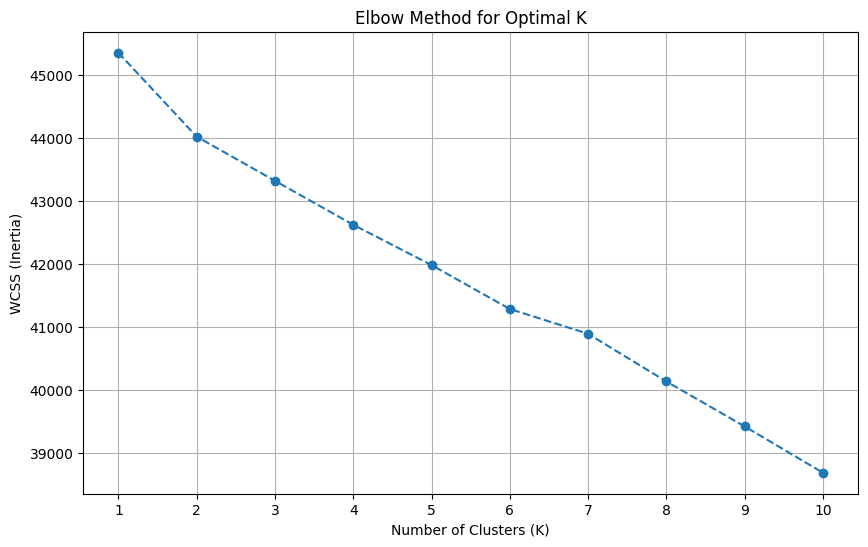

WCSS values for each K:
K=1: WCSS=45356.00
K=2: WCSS=44024.05
K=3: WCSS=43322.35
K=4: WCSS=42625.14
K=5: WCSS=41985.35
K=6: WCSS=41288.30
K=7: WCSS=40894.51
K=8: WCSS=40137.40
K=9: WCSS=39424.63
K=10: WCSS=38689.18


In [6]:
# Calculate Within-Cluster Sum of Squares (WCSS) for K=1 to 10
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

print("WCSS values for each K:")
for k, w in zip(k_range, wcss):
    print(f"K={k}: WCSS={w:.2f}")

### Apply K-Means with Optimal K (e.g., K=4, from elbow curve)

In [7]:
# Choose optimal K (elbow point, typically K=3-5 for customer segmentation)
optimal_k = 4

# Train K-Means model
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataframe for interpretation
df_with_clusters = X.copy()
df_with_clusters['Cluster'] = cluster_labels

print(f"=== K-Means Model Trained (K={optimal_k}) ===")
print(f"Cluster distribution:")
print(df_with_clusters['Cluster'].value_counts().sort_index())

=== K-Means Model Trained (K=4) ===
Cluster distribution:
Cluster
0    181
1    198
2     14
3    274
Name: count, dtype: int64


### Visualize Clusters (2D PCA Reduction)

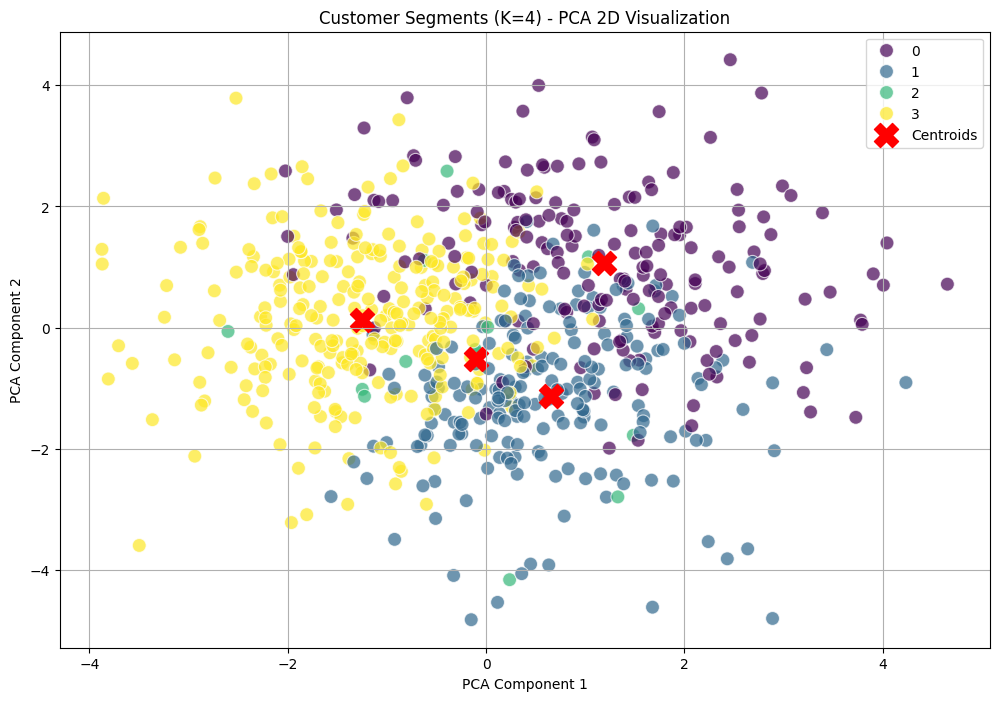

PCA explained variance ratio: 0.07


In [8]:
# Reduce high-dimensional data to 2D using PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create DataFrame for PCA results with cluster labels
pca_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = cluster_labels

# Plot 2D scatter of clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='Cluster', palette='viridis', s=100, alpha=0.7)

# Plot cluster centroids in PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=300, c='red', marker='X', label='Centroids')

plt.title(f'Customer Segments (K={optimal_k}) - PCA 2D Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True)
plt.show()

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_.sum():.2f}")

### Interpret Clustering Results

In [ ]:
# Analyze mean feature values per cluster to interpret segment characteristics
# Select key numerical features for interpretation
key_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

print("=== Cluster Characteristics (Mean Values) ===")
cluster_summary = df_with_clusters.groupby('Cluster')[key_features].mean().round(2)
print(cluster_summary)

# Optional: Silhouette score to evaluate clustering quality
sil_score = silhouette_score(X_scaled, cluster_labels)
print(f"\nSilhouette Score (range -1 to 1, higher is better): {sil_score:.4f}")

print("\n=== Segment Interpretation ===")
print("Example interpretations (adjust based on actual cluster means):")
print("- Cluster 0: Long tenure, low monthly charges (loyal, low-spend customers)")
print("- Cluster 1: Short tenure, high monthly charges (new, high-spend customers)")
print("- Cluster 2: Medium tenure, medium charges (average customers)")
print("- Cluster 3: High total charges, long tenure (high-value loyal customers)")